In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Stage 2 Environment Ready!")

Stage 2 Environment Ready!


In [160]:
import pandas as pd

In [161]:
jobs_df = pd.read_csv("../data/processed/jobs_master.csv")

In [162]:
jobs_df.head(10)

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"linear algebra, quantum algorithms",No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"climate data analysis, energy modeling",Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"linear algebra, qiskit",No,Medium,2025-12-31
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"climate data analysis, energy modeling",No,Large,2025-05-29
4,5,Smart Contract Engineer,Blockchain,London,92575,"rust, solidity",Yes,Small,2025-03-30
5,6,Smart Contract Engineer,Blockchain,Tokyo,173379,"solidity, rust",Yes,Medium,2025-08-10
6,7,Renewable Energy Engineer,Green Tech,New York,99659,"climate data analysis, energy modeling",No,Small,2025-05-27
7,8,Quantum Software Developer,Quantum Computing,London,210842,"qiskit, quantum algorithms",Yes,Large,2025-04-13
8,9,Sustainability Analyst,Green Tech,New York,189475,"climate data analysis, energy modeling",No,Small,2025-04-12
9,10,Blockchain Developer,Blockchain,Tokyo,228992,"ethereum, solidity",No,Large,2025-06-28


In [163]:
jobs_df.shape

(10000, 9)

In [164]:
jobs_df.columns.to_list()

['job_id',
 'job_title',
 'industry',
 'location',
 'salary_usd',
 'skills_required',
 'remote_option',
 'company_size',
 'posting_date']

In [165]:
jobs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   job_id           10000 non-null  int64
 1   job_title        10000 non-null  str  
 2   industry         10000 non-null  str  
 3   location         10000 non-null  str  
 4   salary_usd       10000 non-null  int64
 5   skills_required  10000 non-null  str  
 6   remote_option    10000 non-null  str  
 7   company_size     10000 non-null  str  
 8   posting_date     10000 non-null  str  
dtypes: int64(2), str(7)
memory usage: 703.3 KB


In [166]:
jobs_df["posting_date"] = pd.to_datetime(
    jobs_df["posting_date"],
    errors="coerce"
)

In [167]:
jobs_df.info("posting_date")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   job_id           10000 non-null  int64         
 1   job_title        10000 non-null  str           
 2   industry         10000 non-null  str           
 3   location         10000 non-null  str           
 4   salary_usd       10000 non-null  int64         
 5   skills_required  10000 non-null  str           
 6   remote_option    10000 non-null  str           
 7   company_size     10000 non-null  str           
 8   posting_date     10000 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(2), str(6)
memory usage: 703.3 KB


In [168]:
jobs_df["posting_date"].dtype
jobs_df["posting_date"].isna().sum()

np.int64(0)

In [169]:
jobs_df.head()

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"linear algebra, quantum algorithms",No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"climate data analysis, energy modeling",Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"linear algebra, qiskit",No,Medium,2025-12-31
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"climate data analysis, energy modeling",No,Large,2025-05-29
4,5,Smart Contract Engineer,Blockchain,London,92575,"rust, solidity",Yes,Small,2025-03-30


In [170]:
jobs_df["posting_date"].dtype

dtype('<M8[us]')

# Dataset Overview

## Dataset Name
jobs_master.csv

## Number of rows
10000

## Number of columns
9

## Column Names       
- job_id           10000 non-null  int64         
- job_title        10000 non-null  str           
- industry         10000 non-null  str           
- location         10000 non-null  str           
- salary_usd       10000 non-null  int64         
- skills_required  10000 non-null  str           
- remote_option    10000 non-null  str           
- company_size     10000 non-null  str           
- posting_date     10000 non-null  datetime64[us]

## Initial observations
- posting_date changed from str to datetime .
- No duplicates available.
- No null values in the dataset.
- Ready for analysis.

In [171]:
jobs_df.isnull().sum()

job_id             0
job_title          0
industry           0
location           0
salary_usd         0
skills_required    0
remote_option      0
company_size       0
posting_date       0
dtype: int64

In [172]:
for column in jobs_df.columns:
    print(f"{column}: {jobs_df[column].nunique()} unique values")

job_id: 10000 unique values
job_title: 9 unique values
industry: 4 unique values
location: 6 unique values
salary_usd: 9738 unique values
skills_required: 20 unique values
remote_option: 2 unique values
company_size: 3 unique values
posting_date: 365 unique values


# Data Quality findings

## Missing values
- No missing values 
- No null columns
- No values were replaced

## Unique values
- job_id: 10000 unique values
- job_title: 9 unique values
- industry: 4 unique values
- location: 6 unique values
- salary_usd: 9738 unique values
- skills_required: 20 unique values
- remote_option: 2 unique values
- company_size: 3 unique values
- posting_date: 365 unique values

In [173]:
top_jobs=jobs_df["job_title"].value_counts()
top_jobs.head(25)

job_title
Quantum Software Developer    1278
Smart Contract Engineer       1255
Renewable Energy Engineer     1253
Blockchain Developer          1244
Quantum Researcher            1241
Sustainability Analyst        1237
Ai Engineer                    863
Data Scientist                 817
Ml Researcher                  812
Name: count, dtype: int64

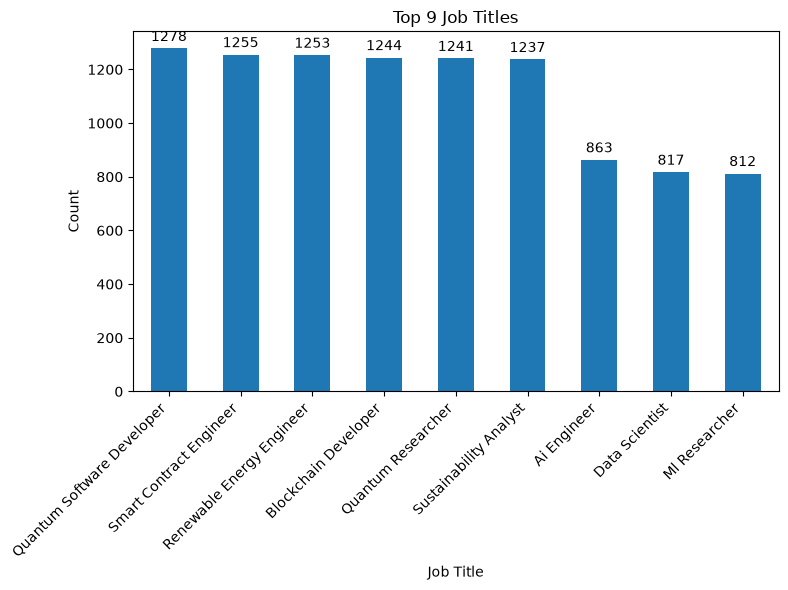

In [198]:
import matplotlib.pyplot as plt

lb = top_jobs.head(9).plot(kind="bar", figsize=(8, 6))
lb.bar_label(lb.containers[0], padding=3)

plt.xlabel("Job Title")
plt.ylabel("Count")
plt.title("Top 9 Job Titles")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    "../outputs/charts/Titles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [175]:
jobs_df["skills_required"].head()

0        linear algebra, quantum algorithms
1    climate data analysis, energy modeling
2                    linear algebra, qiskit
3    climate data analysis, energy modeling
4                            rust, solidity
Name: skills_required, dtype: str

In [176]:
all_skills = (jobs_df["skills_required"]
              .dropna()
                .str.split(",")
                .explode()
                .str.strip()
)

all_skills.value_counts().head(25)

skills_required
climate data analysis    2490
energy modeling          2490
quantum algorithms       1690
tensorflow               1690
ethereum                 1683
qiskit                   1682
solidity                 1669
linear algebra           1666
python                   1657
rust                     1646
pytorch                  1637
Name: count, dtype: int64

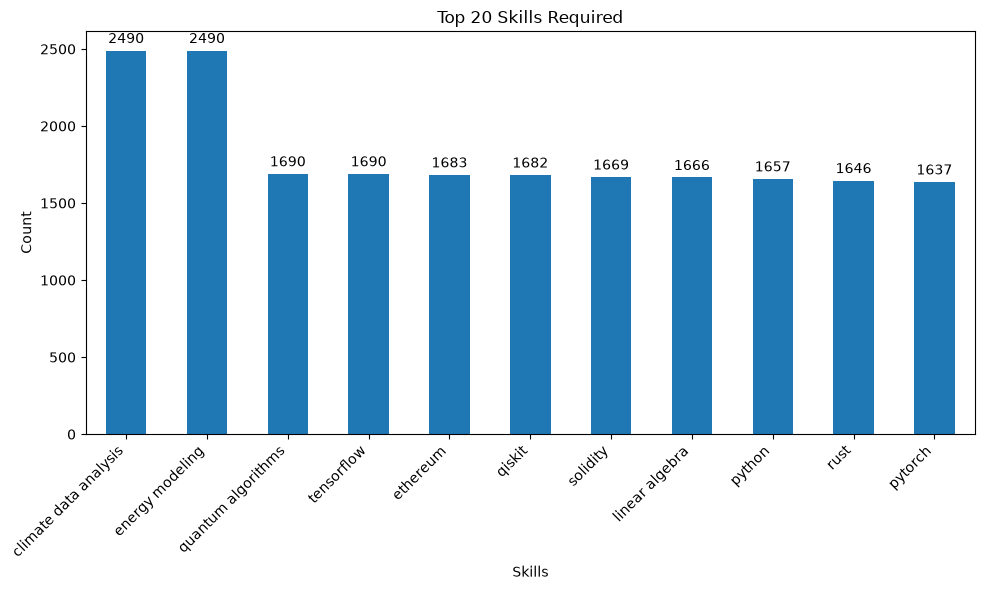

In [197]:
import matplotlib.pyplot as plt 

count = all_skills.value_counts()
lb = count.head(20).plot(kind="bar", figsize=(10, 6))
lb.bar_label(lb.containers[0], padding=3)

plt.xlabel("Skills")
plt.ylabel("Count")
plt.title("Top 20 Skills Required")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    "../outputs/charts/Skills.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [178]:
top_locations = jobs_df["location"].value_counts()
top_locations.head(20)

location
New York     1689
Singapore    1682
Tokyo        1673
Dubai        1660
London       1656
Berlin       1640
Name: count, dtype: int64

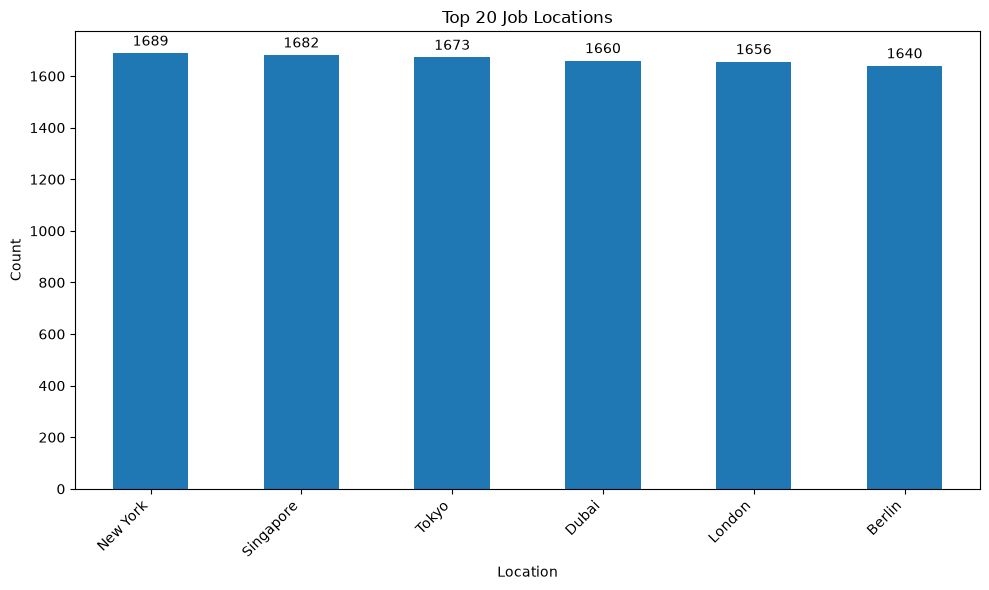

In [196]:
import matplotlib.pyplot as plt

lb = top_locations.head(20).plot(kind="bar",figsize=(10,6))
lb.bar_label(lb.containers[0], padding=3)

plt.xlabel("Location")
plt.ylabel("Count")
plt.title("Top 20 Job Locations")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    "../outputs/charts/Locations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()

In [180]:
jobs_df.head(5)

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"linear algebra, quantum algorithms",No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"climate data analysis, energy modeling",Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"linear algebra, qiskit",No,Medium,2025-12-31
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"climate data analysis, energy modeling",No,Large,2025-05-29
4,5,Smart Contract Engineer,Blockchain,London,92575,"rust, solidity",Yes,Small,2025-03-30


In [181]:
top_industries = jobs_df["industry"].value_counts()
top_industries.head(20)

industry
Quantum Computing    2519
Blockchain           2499
Ai                   2492
Green Tech           2490
Name: count, dtype: int64

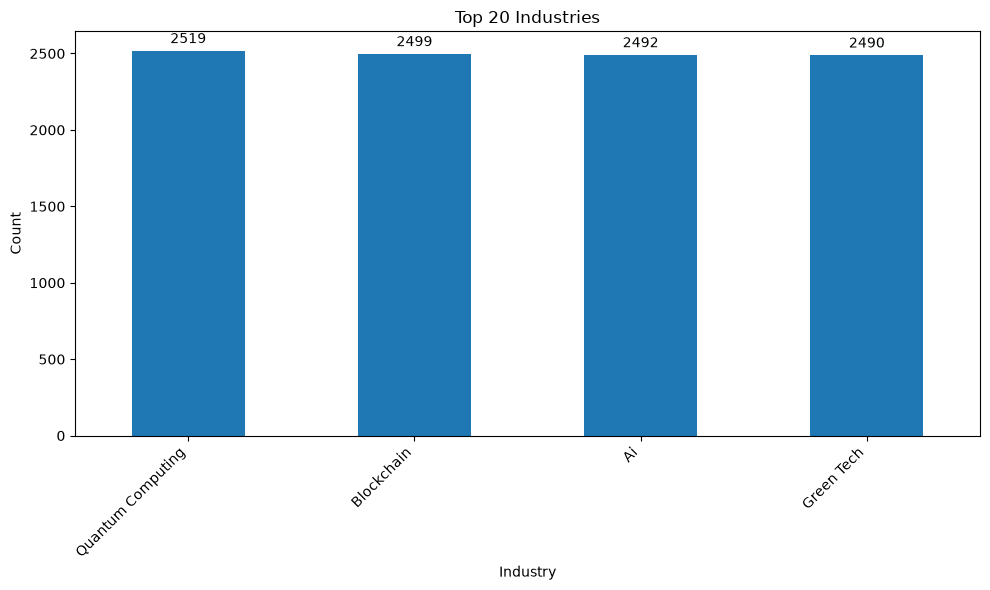

In [195]:
import matplotlib.pyplot as plt

lb = top_industries.head(20).plot(kind="bar",figsize=(10,6))
lb.bar_label(lb.containers[0], padding=3)

plt.xlabel("Industry")
plt.ylabel("Count")
plt.title("Top 20 Industries")
plt.xticks(rotation=45, ha="right")

plt.savefig(
    "../outputs/charts/Industries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [183]:
jobs_df["salary_usd"].describe()

count     10000.000000
mean     150131.524800
std       57534.947278
min       50013.000000
25%      100568.000000
50%      150398.500000
75%      199225.250000
max      249990.000000
Name: salary_usd, dtype: float64

- Average salary : 150.52k
- 50% less than 150.5k
- Top 25% get paid 199k
- Max 249k

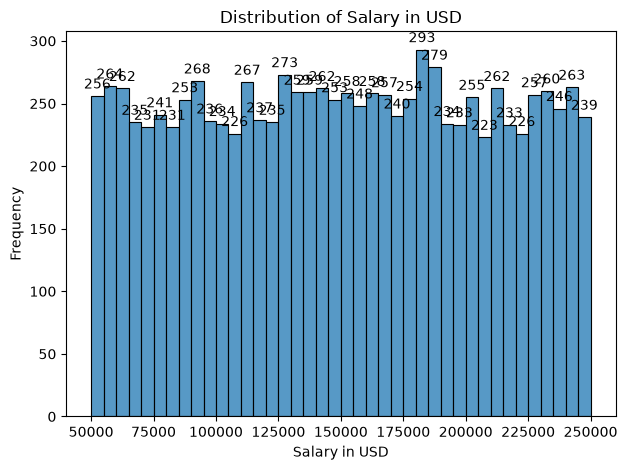

In [199]:
import matplotlib.pyplot as plt

plt.Figure(figsize=(10, 6))

lb = sns.histplot(jobs_df["salary_usd"], bins=40)
lb.bar_label(lb.containers[0], fmt="%d", padding=3)
lb.set_title("Distribution of Salary in USD")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")

plt.savefig(
    "../outputs/charts/Salary_dist.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

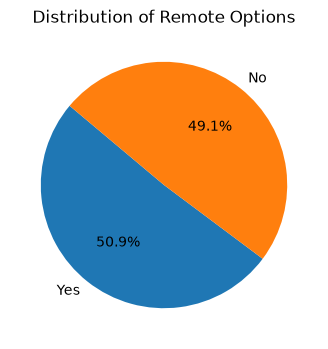

In [200]:
remote_dist = jobs_df["remote_option"].value_counts()
remote_dist.head(3)

plt.figure(figsize=(4, 4))
plt.pie(remote_dist, labels=remote_dist.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Remote Options")

plt.savefig(
    "../outputs/charts/Remote_Options.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

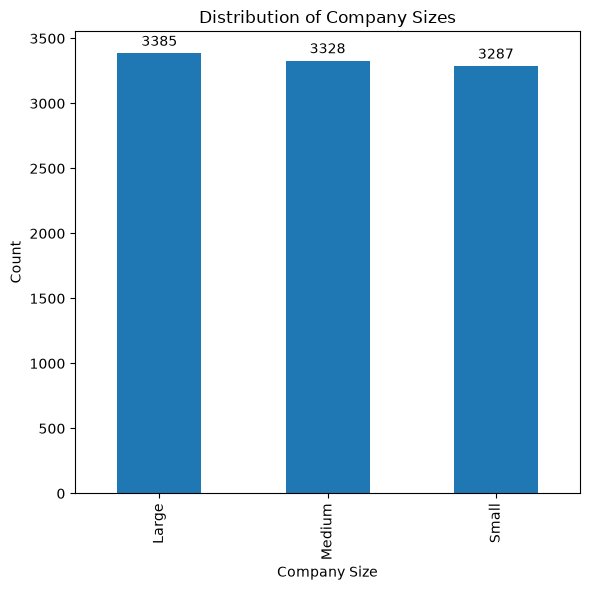

In [201]:
company_size_dist = jobs_df["company_size"].value_counts()
company_size_dist.head(5)

plt.figure(figsize=(6, 6))
chart = company_size_dist.plot(kind="bar", figsize=(6, 6))

plt.xlabel("Company Size")
plt.ylabel("Count")
plt.title("Distribution of Company Sizes")  

chart.bar_label(chart.containers[0], fmt="%d", padding=3)

plt.savefig(
    "../outputs/charts/Company_Size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()